In [1]:
!git clone https://github.com/quark28/miniml.git
%cd miniml

Cloning into 'miniml'...
remote: Enumerating objects: 68, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 68 (delta 26), reused 58 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (68/68), 285.45 KiB | 7.14 MiB/s, done.
Resolving deltas: 100% (26/26), done.
/content/miniml


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression as SklearnLogReg, Perceptron
from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

from miniml.linear_classification import LinearClassification

In [3]:
np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)

In [4]:
X_synth, y_synth = make_classification(
    n_samples=500, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=2.0, random_state=42
)
y_synth_pm = np.where(y_synth == 0, -1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X_synth, y_synth_pm, test_size=0.2, random_state=42
)

print(f"{X_synth.shape[0]} объектов, {X_synth.shape[1]} признака")

500 объектов, 2 признака


In [5]:
cancer = load_breast_cancer()
X_cancer, y_cancer = cancer.data, cancer.target  # y уже в {0, 1}

scaler = StandardScaler()
X_cancer_scaled = scaler.fit_transform(X_cancer)

X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_cancer_scaled, y_cancer, test_size=0.2, random_state=42
)

print(f"{X_cancer.shape[0]} объектов, {X_cancer.shape[1]} признаков")

569 объектов, 30 признаков


In [6]:
losses_to_test = ['hinge', 'hebb', 'logloss', 'fld', 'ann', 'adaboost']

results = []

# sklearn baselines
sk_svm = LinearSVC(max_iter=5000)
sk_svm.fit(X_train, y_train)
sk_svm_pred = sk_svm.predict(X_test)
results.append(('sklearn LinearSVC (hinge)', accuracy_score(y_test, sk_svm_pred), f1_score(y_test, sk_svm_pred)))

sk_logreg = SklearnLogReg(max_iter=5000)
sk_logreg.fit(X_train, y_train)
sk_logreg_pred = sk_logreg.predict(X_test)
results.append(('sklearn LogisticRegression', accuracy_score(y_test, sk_logreg_pred), f1_score(y_test, sk_logreg_pred)))

sk_perc = Perceptron(max_iter=5000)
sk_perc.fit(X_train, y_train)
sk_perc_pred = sk_perc.predict(X_test)
results.append(('sklearn Perceptron (hebb-like)', accuracy_score(y_test, sk_perc_pred), f1_score(y_test, sk_perc_pred)))

for loss in losses_to_test:
    model = LinearClassification(loss=loss)
    model.fit(X_train, y_train, learning_type='gd', n_steps=3000, lr=0.05, lr_type='constant')
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    results.append((f'my {loss}', acc, f1))

df_results = pd.DataFrame(results, columns=['method', 'accuracy', 'f1'])
print(df_results.to_string(index=False))

                        method  accuracy       f1
     sklearn LinearSVC (hinge)      0.96 0.958333
    sklearn LogisticRegression      0.96 0.958333
sklearn Perceptron (hebb-like)      0.96 0.958333
                      my hinge      0.99 0.989899
                       my hebb      0.98 0.979592
                    my logloss      0.98 0.979592
                        my fld      0.97 0.969072
                        my ann      0.99 0.989899
                   my adaboost      0.96 0.958333


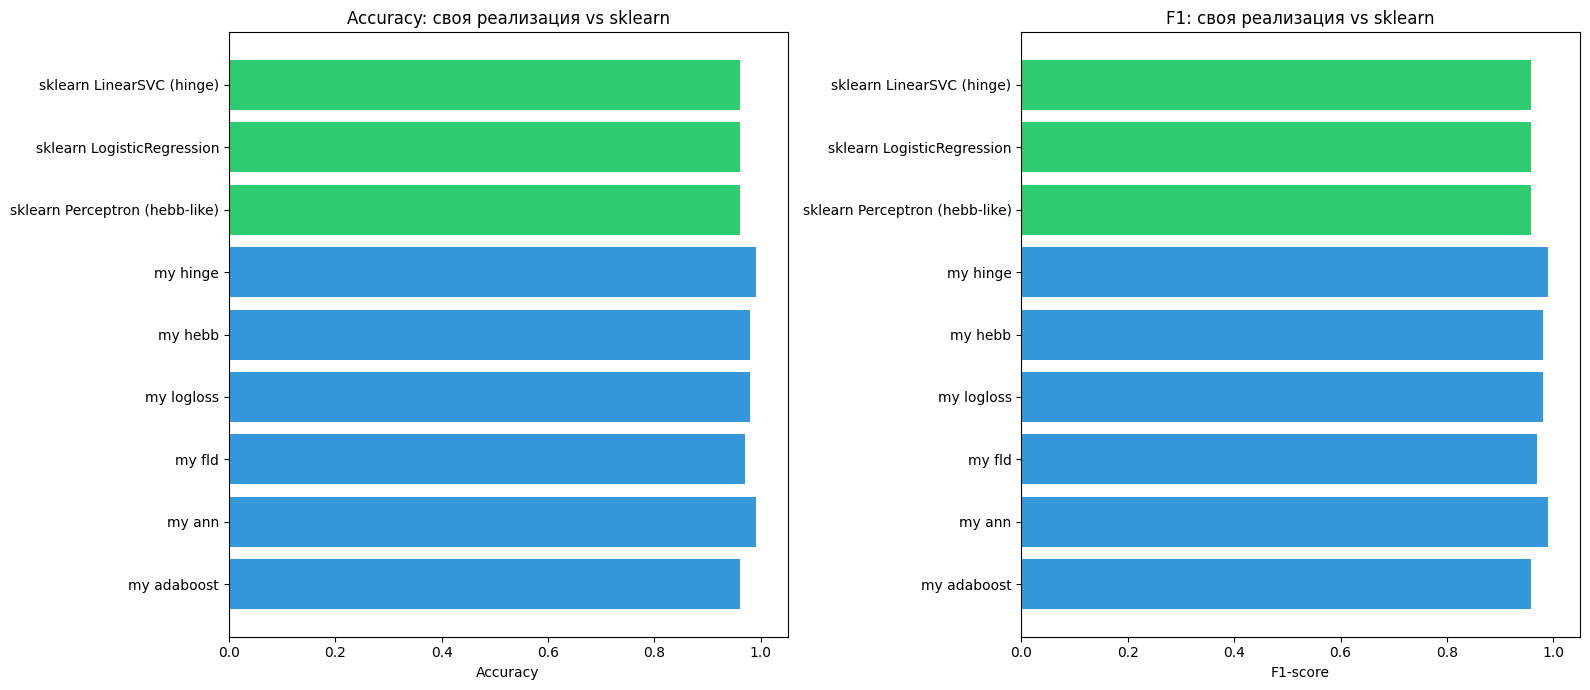

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colors = ['#2ecc71' if 'sklearn' in r[0] else '#3498db' for r in results]

axes[0].barh(df_results['method'], df_results['accuracy'], color=colors)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Accuracy: своя реализация vs sklearn')
axes[0].invert_yaxis()
axes[0].set_xlim(0, 1.05)

axes[1].barh(df_results['method'], df_results['f1'], color=colors)
axes[1].set_xlabel('F1-score')
axes[1].set_title('F1: своя реализация vs sklearn')
axes[1].invert_yaxis()
axes[1].set_xlim(0, 1.05)

plt.tight_layout()
plt.savefig('classification_comparison.png', dpi=100)
plt.show()

/content/miniml/linear_classification.py:60: RuntimeWarning: overflow encountered in exp
  return np.mean(np.exp( - (y_true * y_pred )))
/content/miniml/linear_classification.py:64: RuntimeWarning: overflow encountered in exp
  dL_dM = np.exp(-M)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


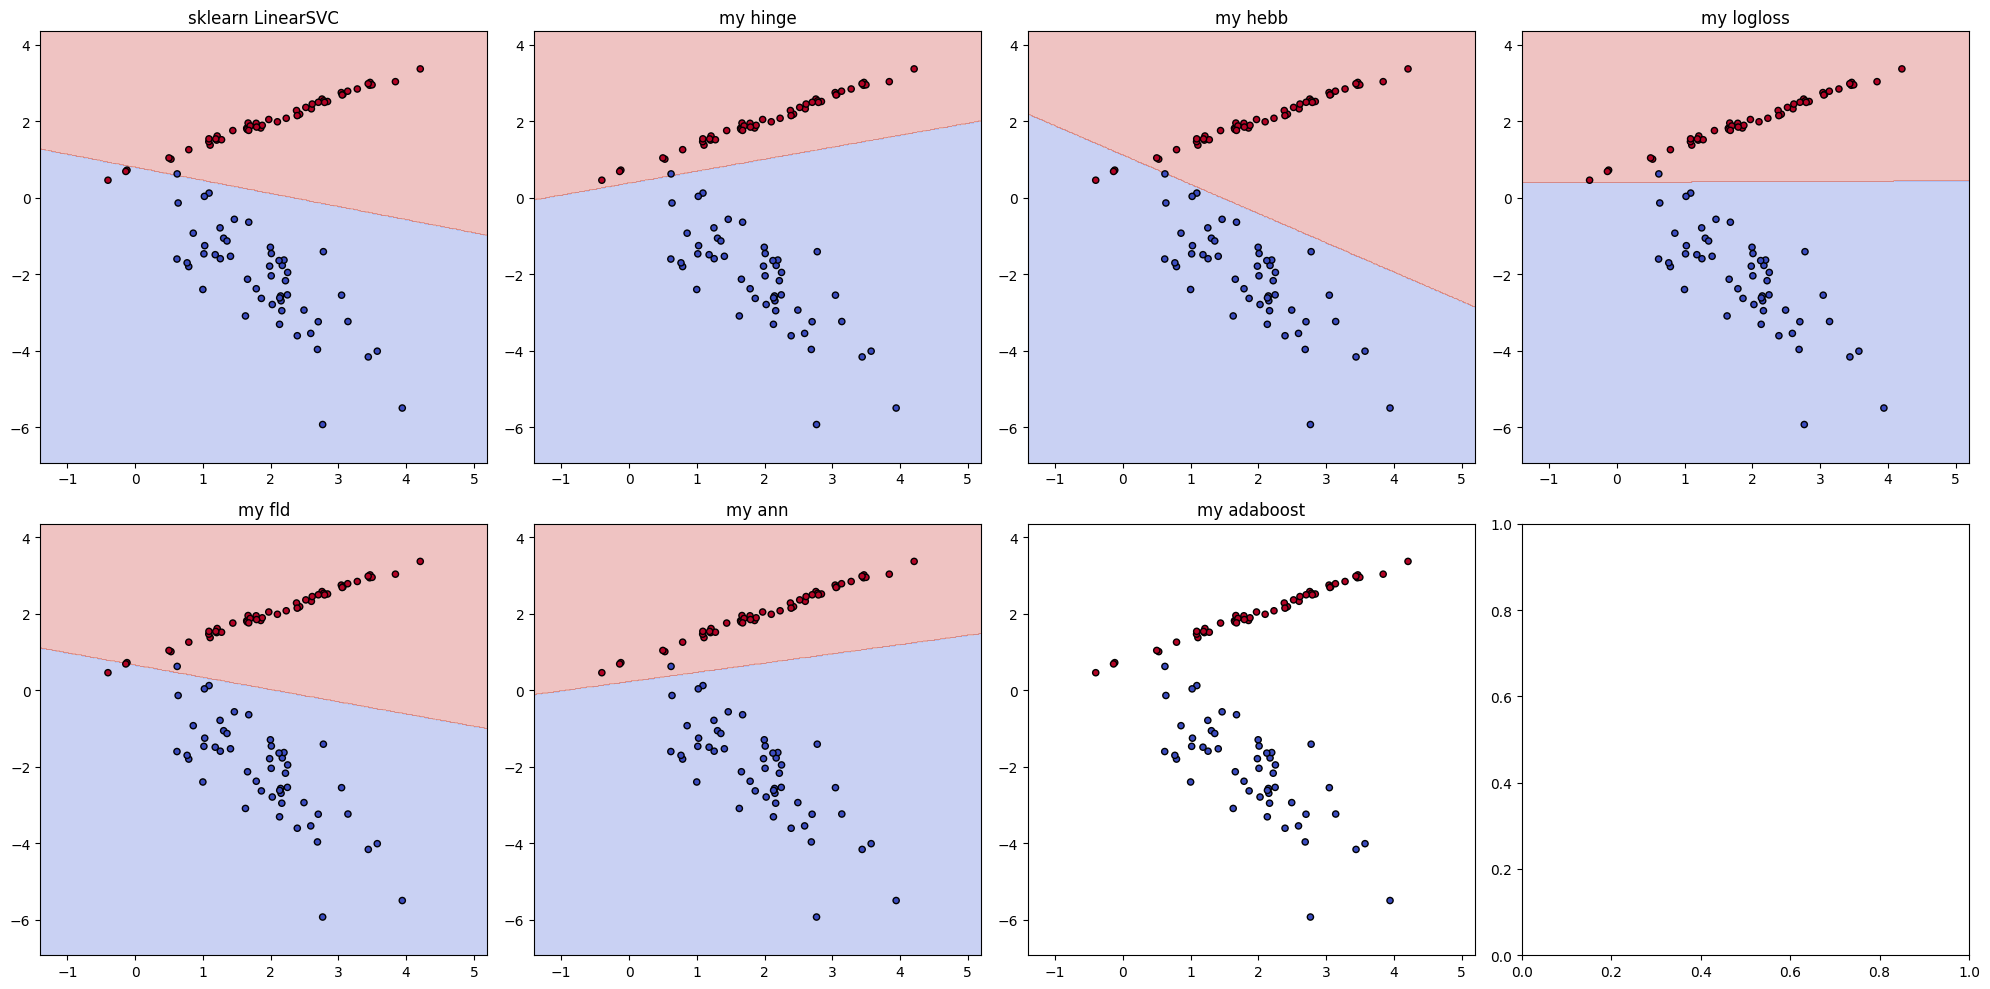

In [8]:
def plot_decision_boundary(model, X, y, ax, title, is_sklearn=False):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    grid = np.c_[xx.ravel(), yy.ravel()]
    if is_sklearn:
        Z = model.predict(grid)
    else:
        Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=20)
    ax.set_title(title)


fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

plot_decision_boundary(sk_svm, X_test, y_test, axes[0], 'sklearn LinearSVC', is_sklearn=True)

for i, loss in enumerate(losses_to_test):
    model = LinearClassification(loss=loss)
    model.fit(X_train, y_train, learning_type='gd', n_steps=3000, lr=0.05, lr_type='constant')
    plot_decision_boundary(model, X_test, y_test, axes[i + 1], f'my {loss}')

plt.tight_layout()
plt.savefig('decision_boundaries.png', dpi=100)
plt.show()

optimizer  accuracy
       gd      0.99
      sag      0.99
     adam      0.99
 momentum      0.99
 nesterov      0.99
  rmsprop      0.99
  adagrad      0.99
    nadam      0.99
      sgd      0.98
 adadelta      0.10


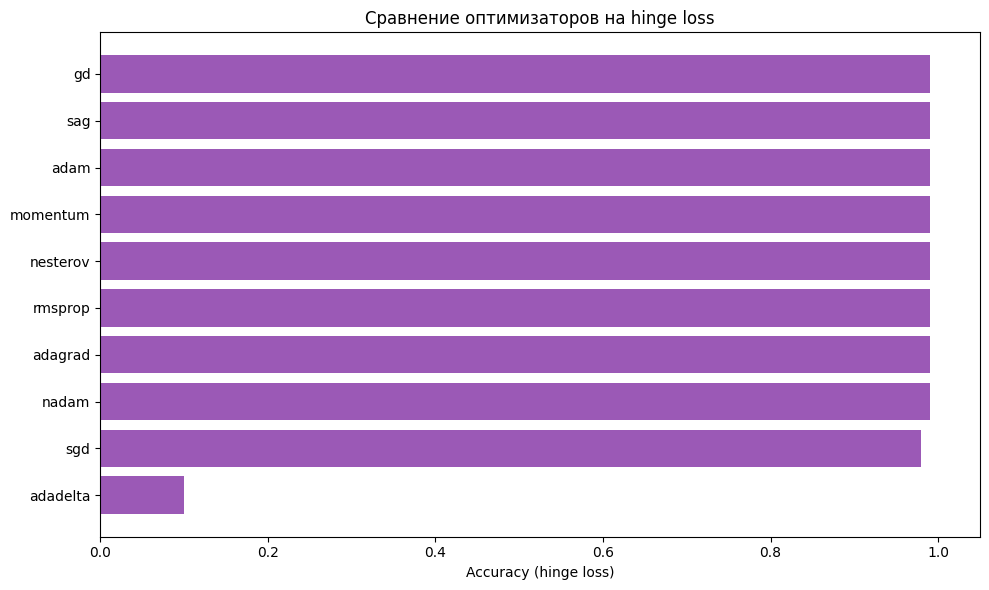

In [9]:
optimizers_to_test = [
    ('gd',       dict(learning_type='gd', n_steps=2000, lr=0.05, lr_type='constant')),
    ('sgd',      dict(learning_type='sgd', n_steps=5000, lr=0.01, lr_type='constant', batch_size=32)),
    ('sag',      dict(learning_type='sag', n_steps=2000, lr=0.01, lr_type='constant', batch_size=16)),
    ('momentum', dict(learning_type='mm', n_steps=2000, lr=0.05, lr_type='constant', gamma=0.9)),
    ('nesterov', dict(learning_type='nag', n_steps=2000, lr=0.05, lr_type='constant', gamma=0.9)),
    ('rmsprop',  dict(learning_type='rms', n_steps=2000, lr=0.05, lr_type='constant', alpha=0.9, const=1e-8)),
    ('adam',     dict(learning_type='adam', n_steps=2000, lr=0.05, lr_type='constant', gamma=0.9, alpha=0.999, const=1e-8)),
    ('nadam',    dict(learning_type='nadam', n_steps=2000, lr=0.05, lr_type='constant', gamma=0.9, alpha=0.999, const=1e-8)),
    ('adagrad',  dict(learning_type='adagrad', n_steps=2000, lr=0.5, lr_type='constant', const=1e-8)),
    ('adadelta', dict(learning_type='adadelta', n_steps=2000, lr=1.0, lr_type='constant', alpha=0.9, const=1e-8)),
]

opt_results = []
for name, kwargs in optimizers_to_test:
    model = LinearClassification(loss='hinge')
    model.fit(X_train, y_train, **kwargs)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    opt_results.append((name, acc))

df_opt = pd.DataFrame(opt_results, columns=['optimizer', 'accuracy']).sort_values('accuracy', ascending=False)
print(df_opt.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(df_opt['optimizer'], df_opt['accuracy'], color='#9b59b6')
plt.xlabel('Accuracy (hinge loss)')
plt.title('Сравнение оптимизаторов на hinge loss')
plt.gca().invert_yaxis()
plt.xlim(0, 1.05)
plt.tight_layout()
plt.savefig('optimizers_comparison.png', dpi=100)
plt.show()

y_test уникальные значения (должны быть 0/1): [0 1]
predict() уникальные значения (должны быть 0/1, не -1/1): [0. 1.]

Method                           Accuracy         F1
sklearn LogisticRegression         0.9737     0.9790
my LinearClassification            0.9649     0.9714


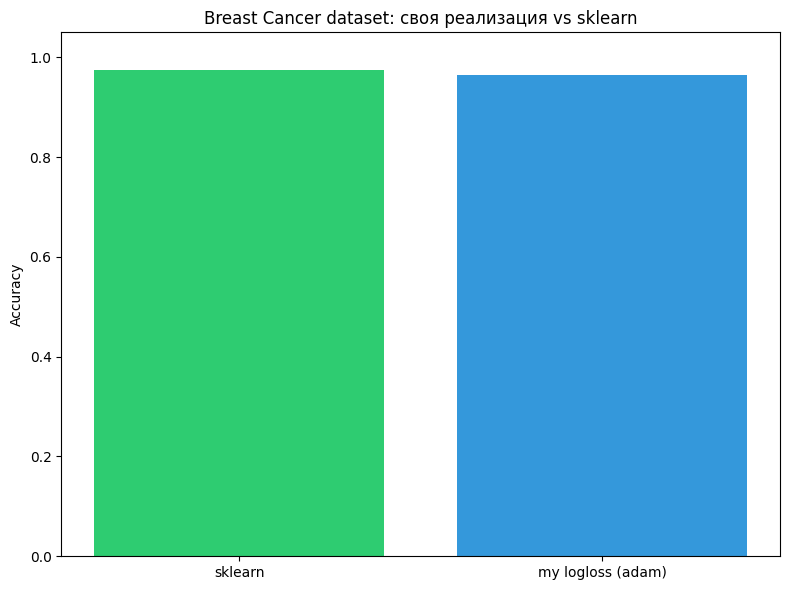

In [10]:
sk_logreg_cancer = SklearnLogReg(max_iter=5000)
sk_logreg_cancer.fit(X_c_train, y_c_train)
sk_cancer_pred = sk_logreg_cancer.predict(X_c_test)
sk_cancer_acc = accuracy_score(y_c_test, sk_cancer_pred)
sk_cancer_f1 = f1_score(y_c_test, sk_cancer_pred)

my_logreg_cancer = LinearClassification(loss='logloss')
my_logreg_cancer.fit(X_c_train, y_c_train, learning_type='adam', n_steps=3000, lr=0.05,
                      lr_type='constant', gamma=0.9, alpha=0.999, const=1e-8)
my_cancer_pred = my_logreg_cancer.predict(X_c_test)  # должно вернуть {0, 1}, не {-1, 1}

print(f"y_test уникальные значения (должны быть 0/1): {np.unique(y_c_test)}")
print(f"predict() уникальные значения (должны быть 0/1, не -1/1): {np.unique(my_cancer_pred)}")

my_cancer_acc = accuracy_score(y_c_test, my_cancer_pred)
my_cancer_f1 = f1_score(y_c_test, my_cancer_pred)

print(f"\n{'Method':<30} {'Accuracy':>10} {'F1':>10}")
print(f"{'sklearn LogisticRegression':<30} {sk_cancer_acc:>10.4f} {sk_cancer_f1:>10.4f}")
print(f"{'my LinearClassification':<30} {my_cancer_acc:>10.4f} {my_cancer_f1:>10.4f}")

plt.figure(figsize=(8, 6))
plt.bar(['sklearn', 'my logloss (adam)'], [sk_cancer_acc, my_cancer_acc], color=['#2ecc71', '#3498db'])
plt.ylabel('Accuracy')
plt.title('Breast Cancer dataset: своя реализация vs sklearn')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig('cancer_comparison.png', dpi=100)
plt.show()

In [11]:
y_c_train_pm = np.where(y_c_train == 0, -1, 1)
y_c_test_pm = np.where(y_c_test == 0, -1, 1)

model_pm = LinearClassification(loss='logloss')
model_pm.fit(X_c_train, y_c_train_pm, learning_type='adam', n_steps=3000, lr=0.05,
             lr_type='constant', gamma=0.9, alpha=0.999, const=1e-8)
pred_pm = model_pm.predict(X_c_test)

print(f"y уже в {{-1,+1}} — predict() вернул: {np.unique(pred_pm)} (ожидается -1/1, т.к. _orig_classes={{-1,1}} не подмножество {{0,1}})")
acc_pm = accuracy_score(y_c_test_pm, pred_pm)
print(f"Accuracy: {acc_pm:.4f}")

y уже в {-1,+1} — predict() вернул: [-1.  1.] (ожидается -1/1, т.к. _orig_classes={-1,1} не подмножество {0,1})
Accuracy: 0.9298


In [13]:
best_loss = df_results.iloc[df_results['accuracy'].idxmax()]
print(f"Лучший лосс на синтетике: {best_loss['method']} (accuracy={best_loss['accuracy']:.4f})")
print(f"Лучший оптимизатор (hinge): {df_opt.iloc[0]['optimizer']} (accuracy={df_opt.iloc[0]['accuracy']:.4f})")
print(f"Breast cancer — своя реализация vs sklearn: {my_cancer_acc:.4f} vs {sk_cancer_acc:.4f}")
print()

Лучший лосс на синтетике: my hinge (accuracy=0.9900)
Лучший оптимизатор (hinge): gd (accuracy=0.9900)
Breast cancer — своя реализация vs sklearn: 0.9649 vs 0.9737

